# HAWK Hochschule für angewandte Wissenschaft und Kunst - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'HAWK Hochschule für angewandte Wissenschaft und Kunst' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/00f5q5839' -- 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,HAWK Hochschule für angewandte Wissenschaft un...,Health Campus Goettingen/University of Applied...,https://openalex.org/W4403135033
1,not assigned,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Resource Management, University of ...",https://openalex.org/W4404033540
2,not assigned,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Resource Management, HAWK Universit...",https://openalex.org/W4396224577
3,not assigned,HAWK Hochschule für angewandte Wissenschaft un...,"Resource Management, HAWK Goettingen, Goetting...",https://openalex.org/W4404970908
4,not assigned,HAWK Hochschule für angewandte Wissenschaft un...,HAWK: Hochschule für angewandte Wissenschaft u...,https://openalex.org/W4391836571


In [188]:
MAPPING_DICT = {
    #'HAWK plus Entrepreneurship': [],
    'Fakultät Ingenieurwissenschaften und Gesundheit': ['plasma', 'eng(.|n|ine(e)?ring) (and|&) h(ea)?lth', 'ingenieurwissenschaften und gesundheit',
                                                        'sciences and technology', 'fluidmechanics', '(health |gesundheits)campus', 'faculty of science and art'
                                                       ],
    'Fakultät Ressourcenmanagement': ['resource mana(na)?gement', 'faculty of management', 'fakultät management', 'ressourcenmanagement'],
    'Fakultät Bauen und Erhalten': ['architecture', 'bauen und erhalten'],
    'Fakultät Gestaltung': ['design', 'gestaltung'],
    'Fakultät soziale Arbeit und Gesundheit': ['soziale arbeit', 'social work'],
    #'Fakultät Management, Soziale Arbeit, Bauen': []
}

In [189]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [190]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [191]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät Ingenieurwissenschaften und Gesundheit,HAWK Hochschule für angewandte Wissenschaft un...,Health Campus Goettingen/University of Applied...,https://openalex.org/W4403135033
1,Fakultät Ressourcenmanagement,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Resource Management, University of ...",https://openalex.org/W4404033540
2,Fakultät Ressourcenmanagement,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Resource Management, HAWK Universit...",https://openalex.org/W4396224577
3,Fakultät Ressourcenmanagement,HAWK Hochschule für angewandte Wissenschaft un...,"Resource Management, HAWK Goettingen, Goetting...",https://openalex.org/W4404970908
4,Fakultät soziale Arbeit und Gesundheit,HAWK Hochschule für angewandte Wissenschaft un...,HAWK: Hochschule für angewandte Wissenschaft u...,https://openalex.org/W4391836571
...,...,...,...,...
363,Fakultät soziale Arbeit und Gesundheit,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Social Work and Health, HAWK Univer...",https://openalex.org/W4406593658
364,Fakultät Gestaltung,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Design, HAWK University of Applied ...",https://openalex.org/W4406593658
365,Fakultät Ingenieurwissenschaften und Gesundheit,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Engineering and Health, University ...",https://openalex.org/W3157757543
366,None,HAWK Hochschule für angewandte Wissenschaft un...,HAWK—Hochschule für Angewandte Wissenschaften ...,https://openalex.org/W3191705885


In [192]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()

array(['University of Applied Sciences and Art, Hildesheim, Germany',
       'Hochschule für angewandte Wissenschaft und Kunst, Hildesheim/Holzminden/Göttingen, Deutschland',
       'Hochschule für angewandte Wissenschaft und Kunst Hildesheim, Hildesheim, Germany',
       'MALTE BELLMANN, PhD, is affiliated with Research Biomechanics, Ottobock SE & Co. KGaA, Göttingen, Germany; HAWK University of Applied Sciences and Art, Göttingen, Germany',
       'HAWK University of Applied Sciences and Art, Göttingen, Germany',
       'HAWK University of Applied Sciences and Arts, Von-Ossietzky-Str. 99, 37085 Göttingen, Germany',
       'HAWK, University of applied sciences and arts, Göttingen, Germany',
       'HAWK University of Applied Sciences and Arts, Göttingen, Deutschland',
       'University of Applied Sciences and Arts (HAWK), G&#x00F6;ttingen, Germany',
       'Hochschule für angewandte Wissenschaft und Kunst Hildesheim/Holzminden/Göttingen, Hildesheim, Deutschland',
       'HAWK Hochsch

In [193]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Fakultät Bauen und Erhalten,2
1,Fakultät Gestaltung,6
2,Fakultät Ingenieurwissenschaften und Gesundheit,125
3,Fakultät Ressourcenmanagement,103
4,Fakultät soziale Arbeit und Gesundheit,47
5,NaN,85


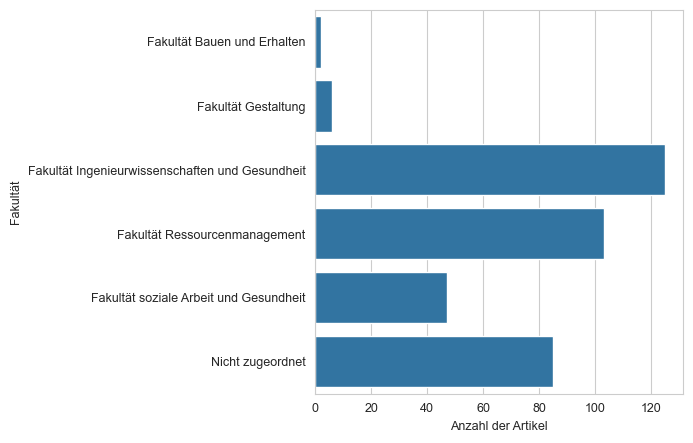

In [194]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [195]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.7690217391304348